# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [1]:
# Dataset Used: Heart Disease UCI Dataset
# Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease
#
# Reason for using this dataset:
# - Public, open, legal for educational use
# - Mix of numerical and categorical features
# - Good for EDA, cleaning, preprocessing, and ML experiments
#
# Files in project:
# - heart_raw.csv                → raw dataset (namadataset_raw)
# - heart_clean.csv              → cleaned dataset (namadataset_preprocessing)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [9]:
#Type your code here

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [10]:
from google.colab import files
uploaded = files.upload()

Saving heart_raw.csv to heart_raw.csv


In [11]:
#Type your code here

# Load raw dataset (from project root folder)
df = pd.read_csv("/content/heart_raw.csv")

# Show first rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1.564334,0.720325,0.812897,-0.658682,-0.455971,0.0,1.015660,-0.812527,1.332615,1.533515,0.720799,1.905959,1.129936,1
1,-0.182473,0.720325,-1.831070,-0.658682,-0.296282,0.0,-0.990736,1.462145,-0.750404,-0.197064,-0.985798,-0.821680,-0.925653,0
2,0.770331,-1.388262,0.812897,0.656232,0.433725,0.0,1.015660,0.626551,-0.750404,2.494947,2.427395,1.905959,-0.925653,3
3,-0.023672,-1.388262,0.812897,-0.658682,2.395617,0.0,-0.990736,0.765817,1.332615,-0.389350,-0.985798,-0.821680,-0.925653,0
4,0.929131,0.720325,0.812897,-0.001225,0.114347,0.0,1.015660,0.023067,-0.750404,0.379796,0.720799,0.542139,1.129936,2


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Dataset shape: (161, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       161 non-null    float64
 1   sex       161 non-null    float64
 2   cp        161 non-null    float64
 3   trestbps  161 non-null    float64
 4   chol      161 non-null    float64
 5   fbs       161 non-null    float64
 6   restecg   161 non-null    float64
 7   thalach   161 non-null    float64
 8   exang     161 non-null    float64
 9   oldpeak   161 non-null    float64
 10  slope     161 non-null    float64
 11  ca        161 non-null    float64
 12  thal      161 non-null    float64
 13  target    161 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 17.7 KB


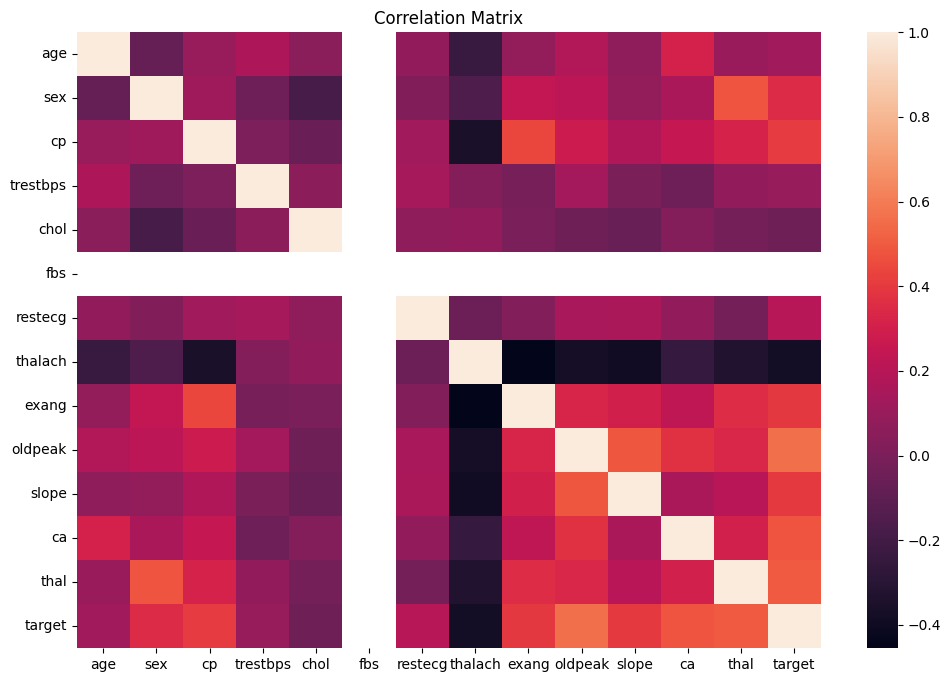

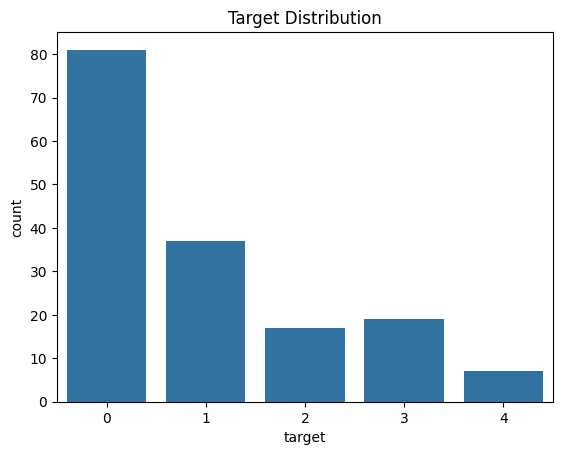

In [12]:
#Type your code here

print("Dataset shape:", df.shape)

df.info()
df.describe()

# Check missing values
df.isnull().sum()

# Correlation (numerical)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Matrix")
plt.show()

# Distribution of target
sns.countplot(x=df["target"])
plt.title("Target Distribution")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
df = df.drop_duplicates()

In [14]:
df = df.fillna(df.median(numeric_only=True))

In [15]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numerical_features = [col for col in df.columns if col not in categorical_features + ["target"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [17]:
import os

# Create the directory if it does not exist
os.makedirs('/content/preprocessing', exist_ok=True)

df.to_csv("/content/preprocessing/heart_clean.csv", index=False)
print("Saved heart_clean.csv")

Saved heart_clean.csv
